# Test completo di archivio, analisi e visualizzazione Sudoku

Questo notebook verifica l'intero flusso:

1. genera un nuovo Sudoku con soluzione unica;
2. lo salva nell'archivio;
3. lo ricarica dal file;
4. esegue l'analisi completa, che al primo accesso deve essere calcolata e salvata;
5. visualizza il risultato in tutti i modi disponibili;
6. richiede nuovamente la stessa analisi e verifica che venga restituita dalla cache in memoria.

Il notebook presuppone questi moduli nello stesso progetto:

- `sudoku_solver.py`
- `sudoku_archive.py`
- `sudoku_visualization.py`


In [2]:
import random
import time

import matplotlib.pyplot as plt
import pandas as pd

import sudoku_solver as ss
import sudoku_archive as sa
import sudoku_visualization as sv
import sudoku_generator as sg

plt.rcParams["figure.figsize"] = (7, 7)


## 1. Generazione di un nuovo Sudoku

Viene usato un seed casuale, così ogni esecuzione completa del notebook tende a produrre un Sudoku nuovo. In questo modo non dovrebbe esistere già un'analisi salvata per la stessa griglia.


Seed: 621046452
Nome: generated_621046452
Numero di indizi: 30


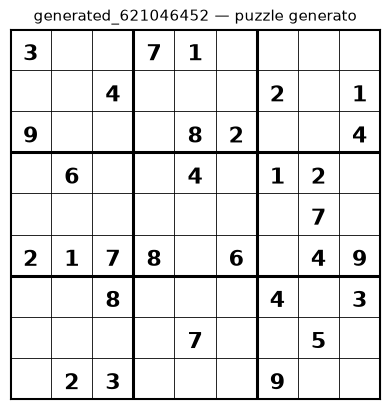

In [3]:
seed = random.SystemRandom().randrange(1, 10**9)
rng = random.Random(seed)

generated_puzzle, generated_solution = sg.generate_unique_puzzle(
    target_clues=30,
    rng=rng,
)

puzzle_name = f"generated_{seed}"

print("Seed:", seed)
print("Nome:", puzzle_name)
print("Numero di indizi:", int((generated_puzzle != 0).sum()))

sv.draw_grid(
    generated_puzzle,
    title=f"{puzzle_name} — puzzle generato",
)
plt.show()


## 2. Salvataggio del Sudoku

Il Sudoku viene salvato nella cartella `puzzles` dell'archivio. Il nome del file dipende dall'identificatore derivato dalla griglia.


In [4]:
saved_info = sa.save_sudoku(
    generated_puzzle,
    name=puzzle_name,
    metadata={
        "seed": seed,
        "target_clues": 30,
        "purpose": "test completo archivio e cache",
    },
)

print("Sudoku salvato")
print("ID:", saved_info["id"])
print("Nome:", saved_info["name"])
print("Percorso:", saved_info["path"])


Sudoku salvato
ID: 5799d0ae72e7f8e5753a
Nome: generated_621046452
Percorso: sudoku_data\puzzles\5799d0ae72e7f8e5753a.json


## 3. Caricamento del Sudoku

Il Sudoku viene ricaricato usando il nome assegnato. La griglia caricata viene confrontata con quella generata.


Sudoku caricato
ID: 5799d0ae72e7f8e5753a
Nome: generated_621046452
Percorso: sudoku_data\puzzles\5799d0ae72e7f8e5753a.json
Griglia identica all'originale: True


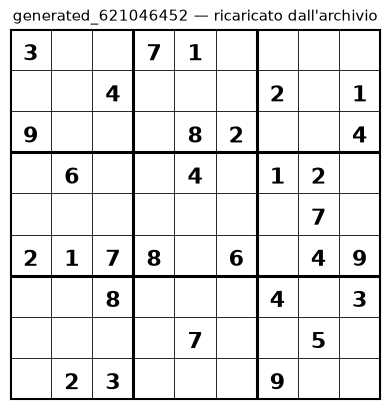

In [5]:
loaded_info = sa.load_sudoku(puzzle_name)
loaded_puzzle = loaded_info["grid"]

print("Sudoku caricato")
print("ID:", loaded_info["id"])
print("Nome:", loaded_info["name"])
print("Percorso:", loaded_info["path"])
print("Griglia identica all'originale:", (loaded_puzzle == generated_puzzle).all())

sv.draw_grid(
    loaded_puzzle,
    title=f"{loaded_info['name']} — ricaricato dall'archivio",
)
plt.show()


## 4. Prima analisi completa

Dato che il Sudoku è appena stato generato, la sua analisi non dovrebbe essere presente né nella cache in memoria né nell'archivio. La prima chiamata deve quindi:

1. eseguire il solver;
2. costruire la catena logica;
3. valutare la difficoltà;
4. salvare automaticamente l'analisi;
5. inserirla nella cache in memoria.


In [6]:
start = time.perf_counter()

first_result = sa.analyse_puzzle_cached(
    loaded_puzzle,
    name=loaded_info["name"],
)

first_elapsed = time.perf_counter() - start

print("Prima analisi completata")
print("Tempo:", round(first_elapsed, 4), "secondi")
print("Stato:", first_result["status"])
print("Valutazione:", first_result["grading"])
print("Numero di step:", len(first_result["chain"]))


Prima analisi completata
Tempo: 0.1506 secondi
Stato: solved
Valutazione: {'label': 'Fondamentale', 'max_difficulty': 1, 'score': 1.0, 'histogram': {1: 51, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0}, 'status': 'solved', 'n_steps': 51}
Numero di step: 51


## 5. Visualizzazione della griglia risolta


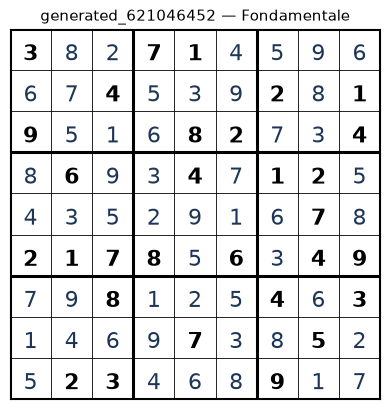

In [7]:
sv.draw_grid(
    first_result["solved_grid"],
    given_mask=(first_result["original"] != 0),
    title=(
        f"{first_result['name']} — "
        f"{first_result['grading']['label']}"
    ),
)
plt.show()


## 6. Catena di difficoltà

Mostra il livello di difficoltà usato a ogni step e il numero complessivo di passaggi per livello.


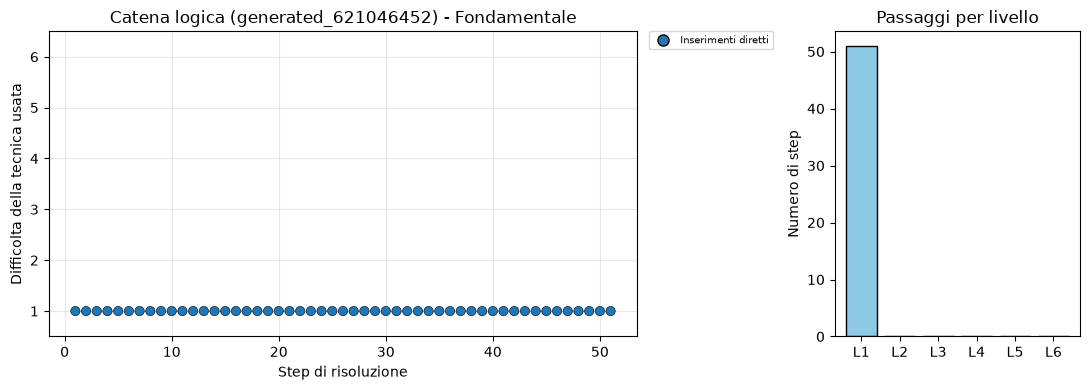

In [8]:
sv.plot_difficulty_chain(first_result)


## 7. Passaggio più difficile

Viene visualizzato lo stato della griglia in corrispondenza del passaggio con difficoltà massima.


Indice: 0
Step: 1
Tecnica: Hidden Single
Difficoltà: 1
Descrizione: Nel row che contiene R1C3, il numero 2 puo comparire solo li.


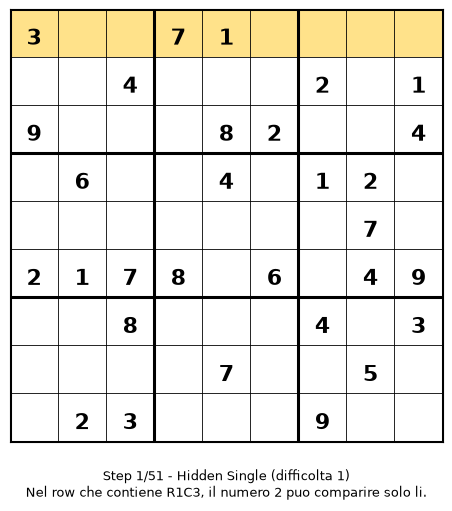

In [9]:
if first_result["chain"]:
    hardest_index = max(
        range(len(first_result["chain"])),
        key=lambda index: first_result["chain"][index]["difficulty"],
    )

    hardest_move = first_result["chain"][hardest_index]

    print("Indice:", hardest_index)
    print("Step:", hardest_move["step"])
    print("Tecnica:", hardest_move["technique"])
    print("Difficoltà:", hardest_move["difficulty"])
    print("Descrizione:", hardest_move["description"])

    sv.draw_step(first_result, hardest_index)
else:
    print("Nessun passaggio disponibile.")


## 8. Tabella completa della catena


In [10]:
chain_dataframe = sv.summary_dataframe(first_result)
chain_dataframe


,step,tecnica,famiglia,difficolta,n_alternative,descrizione
0,1,Hidden Single,Inserimenti diretti,1,64,"Nel row che contiene R1C3, il numero 2 puo com..."
1,2,Hidden Single,Inserimenti diretti,1,59,"Nel row che contiene R1C6, il numero 4 puo com..."
2,3,Hidden Single,Inserimenti diretti,1,55,"Nel row che contiene R1C8, il numero 9 puo com..."
3,4,Hidden Single,Inserimenti diretti,1,54,"Nel row che contiene R3C3, il numero 1 puo com..."
4,5,Hidden Single,Inserimenti diretti,1,50,"Nel row che contiene R4C6, il numero 7 puo com..."
5,6,Hidden Single,Inserimenti diretti,1,45,"Nel row che contiene R4C4, il numero 3 puo com..."
6,7,Naked Single,Inserimenti diretti,1,57,La cella R6C5 ha un solo candidato possibile: 5.
7,8,Naked Single,Inserimenti diretti,1,59,La cella R6C7 ha un solo candidato possibile: 3.
8,9,Naked Single,Inserimenti diretti,1,56,La cella R9C5 ha un solo candidato possibile: 6.
9,10,Hidden Single,Inserimenti diretti,1,56,"Nel row che contiene R3C8, il numero 3 puo com..."


## 9. Frequenza delle tecniche effettivamente usate


In [11]:
technique_counts = (
    chain_dataframe["tecnica"]
    .value_counts()
    .rename_axis("tecnica")
    .reset_index(name="numero_step")
)

technique_counts


,tecnica,numero_step
0,Naked Single,43
1,Hidden Single,8


## 10. Attività delle tecniche durante la risoluzione

Se `sudoku_visualization.py` contiene `plot_technique_activity`, viene mostrata la heatmap con:

- righe: tecniche;
- colonne: step;
- valori: numero di applicazioni disponibili in quello stato.

Le analisi devono contenere `applicable_by_technique` perché questa visualizzazione sia significativa.


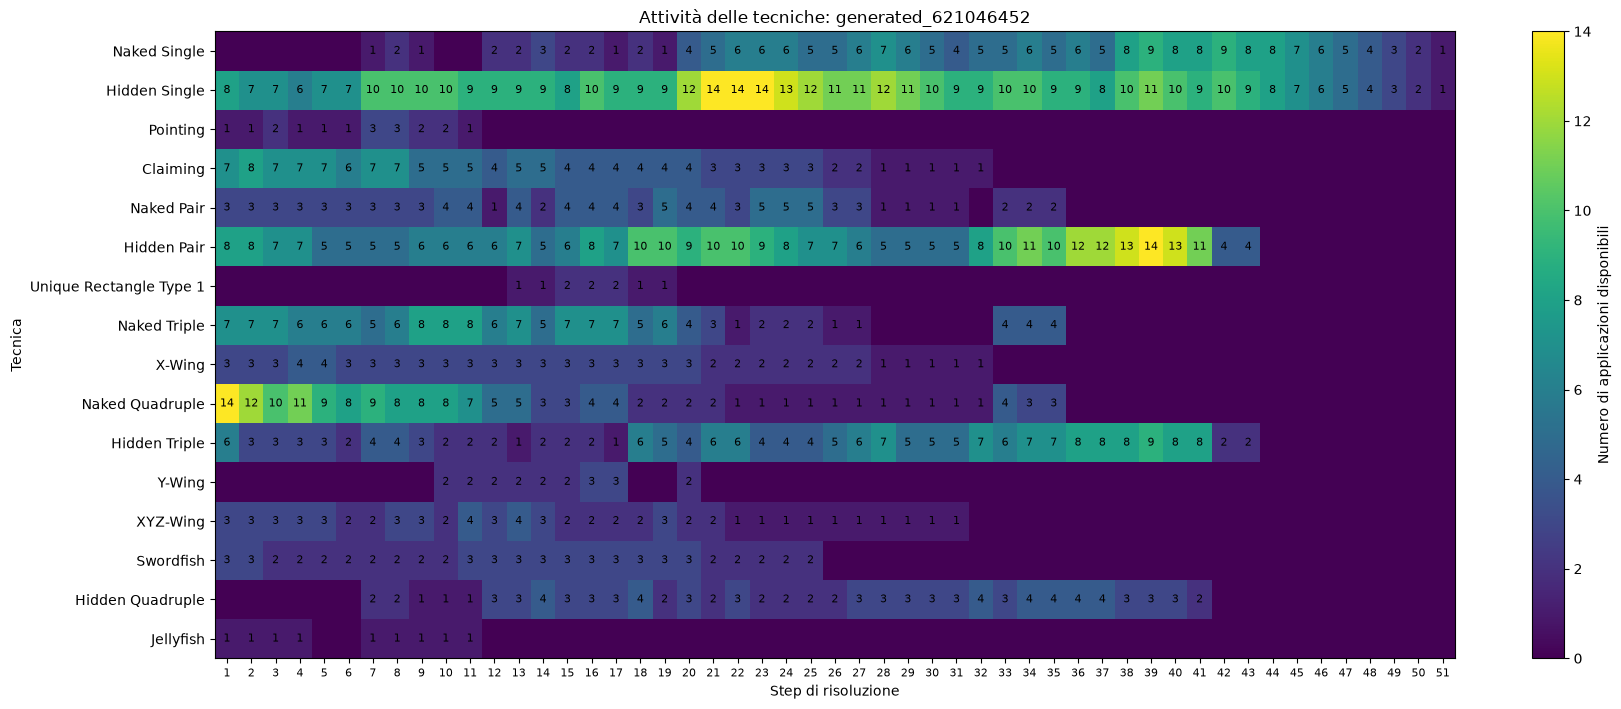

In [12]:
if hasattr(sv, "plot_technique_activity"):
    has_activity_data = any(
        "applicable_by_technique" in step
        for step in first_result["chain"]
    )

    if has_activity_data:
        sv.plot_technique_activity(first_result)
    else:
        print(
            "La funzione esiste, ma l'analisi non contiene "
            "'applicable_by_technique'. Aggiorna solve_and_log "
            "e incrementa ANALYSIS_VERSION."
        )
else:
    print(
        "plot_technique_activity non è presente in "
        "sudoku_visualization.py."
    )


## 11. Galleria

La galleria è pensata per più Sudoku, ma può essere usata anche con un solo risultato per verificare la vista riepilogativa.


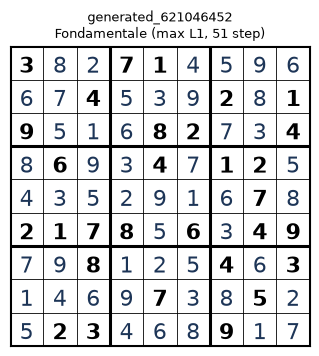

In [13]:
sv.gallery([first_result], ncols=1)


## 12. Riepilogo sintetico


In [14]:
grading = first_result["grading"]

summary = pd.DataFrame([
    {
        "nome": first_result["name"],
        "stato": first_result["status"],
        "difficoltà": grading["label"],
        "livello_massimo": grading["max_difficulty"],
        "punteggio": grading["score"],
        "numero_step": grading.get("n_steps", len(first_result["chain"])),
        "solvibile_verificato": first_result.get(
            "backtracking_verified_solvable"
        ),
    }
])

summary


,nome,stato,difficoltà,livello_massimo,punteggio,numero_step,solvibile_verificato
0,generated_621046452,solved,Fondamentale,1,1.0,51,None


## 13. Seconda richiesta della stessa analisi

La stessa analisi viene richiesta di nuovo nello stesso processo Python. Se la cache in memoria funziona, `analyse_puzzle_cached` deve restituire lo stesso oggetto già presente in `_ANALYSIS_MEMORY_CACHE`, senza rileggere o ricalcolare l'analisi.

Il controllo più diretto è `second_result is first_result`.


In [15]:
start = time.perf_counter()

second_result = sa.analyse_puzzle_cached(
    loaded_puzzle,
    name=loaded_info["name"],
)

second_elapsed = time.perf_counter() - start

print("Seconda richiesta completata")
print("Tempo:", round(second_elapsed, 6), "secondi")
print("Stesso oggetto in memoria:", second_result is first_result)
print(
    "Contenuto equivalente:",
    second_result["grading"] == first_result["grading"]
    and len(second_result["chain"]) == len(first_result["chain"]),
)

if second_result is first_result:
    print("OK: l'analisi è stata presa dalla cache in memoria.")
else:
    print(
        "La seconda analisi non è lo stesso oggetto. "
        "Controlla l'implementazione di analyse_puzzle_cached."
    )


Seconda richiesta completata
Tempo: 0.002963 secondi
Stesso oggetto in memoria: True
Contenuto equivalente: True
OK: l'analisi è stata presa dalla cache in memoria.


## 14. Controllo dell'archivio

Mostra l'elenco dei Sudoku salvati e verifica che quello appena creato risulti analizzato.


In [16]:
archive_dataframe = pd.DataFrame(sa.list_sudokus())

if not archive_dataframe.empty:
    archive_dataframe = archive_dataframe[
        archive_dataframe["id"] == loaded_info["id"]
    ]

archive_dataframe


,id,name,clues,analysed,updated_at
0,5799d0ae72e7f8e5753a,generated_621046452,30,True,2026-07-16T10:13:25.802671+00:00


## Risultato atteso

Al termine del notebook dovresti vedere:

- il Sudoku generato;
- il file salvato e poi ricaricato;
- la prima analisi completa;
- tutte le visualizzazioni disponibili;
- la tabella della catena;
- la seconda richiesta servita dalla cache;
- `Stesso oggetto in memoria: True`;
- il Sudoku segnato come analizzato nell'elenco dell'archivio.
